# <b><font color='chocolate'>Продвинутые возможности matplotlib</font></b>

### <font color='chocolate'>1. Дополнительные возможности</font>

##### <font color='chocolate'>1.1. Временные ряды и графики дат</font>

In [1]:
# %pip install --ignore-installed --no-cache-dir matplotlib==3.10.8 ipympl ipywidgets
# %pip install -U "tornado>=6.2"

In [2]:
# мпорт бибилиотек
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
%matplotlib inline

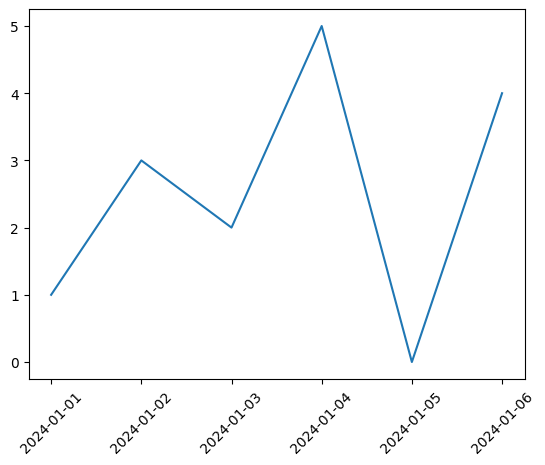

In [4]:
dates = pd.date_range('20240101', periods = 6)
values = [1, 3, 2, 5, 0, 4]

plt.plot(dates, values)
plt.xticks(rotation = 45) 
plt.show()

##### <font color='chocolate'>1.2. Тепловые карты</font>
Цвета представляют значения.

In [5]:
df_sales = pd.read_csv('../data/sales_data (1).csv')
df_sales.head()

,Страна,Товар,Количество
0,Китай,Камера,147
1,Бразилия,Наушники,55
2,Германия,Камера,238
3,Бразилия,Камера,356
4,Бразилия,Телевизор,173


In [6]:
# Построение сводной таблицы: по строкам - страны, по столбцам - товары, значения - общее кол-во проданных товаров
df_sales_crosstab = pd.crosstab(df_sales['Страна'], df_sales['Товар'], values = df_sales['Количество'], aggfunc = 'sum')
df_sales_crosstab

Товар,Камера,Наушники,Ноутбук,Планшет,Смартфон,Телевизор
Страна,,,,,,
Бразилия,7222,6625,7492,6934,7390,7264
Германия,6957,5963,4697,8042,5895,8326
ндия,5702,7081,9208,6500,5302,6006
Китай,8326,7996,8088,6987,7381,5794
США,7834,6727,7640,6358,6901,6494


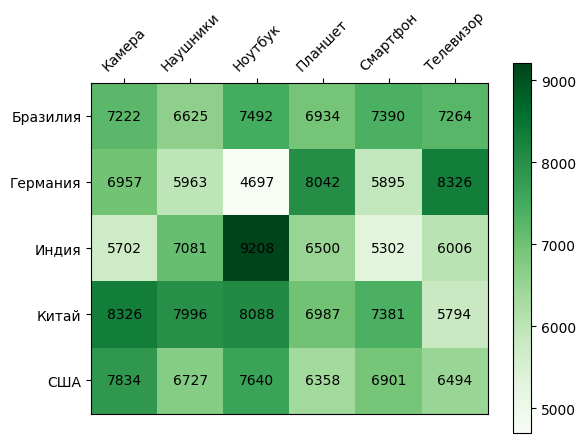

In [7]:
# Построение heatmap
fig, ax = plt.subplots()
plt.imshow(df_sales_crosstab, cmap = 'Greens')
plt.colorbar()
plt.xticks(range(len(df_sales_crosstab.columns)), labels = df_sales_crosstab.columns, rotation = 45)
plt.yticks(range(len(df_sales_crosstab.index)), labels = df_sales_crosstab.index)
# Переносим ось X наверх
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
# Делаем подписи данных
for i in range(df_sales_crosstab.shape[0]):
    for j in range(df_sales_crosstab.shape[1]):
        ax.text(j, i, str(df_sales_crosstab.iloc[i, j]),
                ha = "center", va = "center", color = "black")
plt.show()

[Colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html?utm_source=chatgpt.com)

##### <font color='chocolate'>1.3. Цветовые карты</font>
нтенсивность цвета отображает количество значений в интервале.<br>
Практическая польза:
- Быстро увидеть закономерности в больших данных.
- Определять скопления, тренды и аномалии.
- Цветовая карта делает график читаемым, даже если точек десятки тысяч.

In [8]:
df_traffic = pd.read_csv('../data/gps_traffic_data.csv')
df_traffic.head()

,longitude,latitude
0,0.745071,-0.678495
1,-0.207396,-0.305499
2,0.971533,-0.597381
3,2.284545,0.110418
4,-0.351230,1.197179


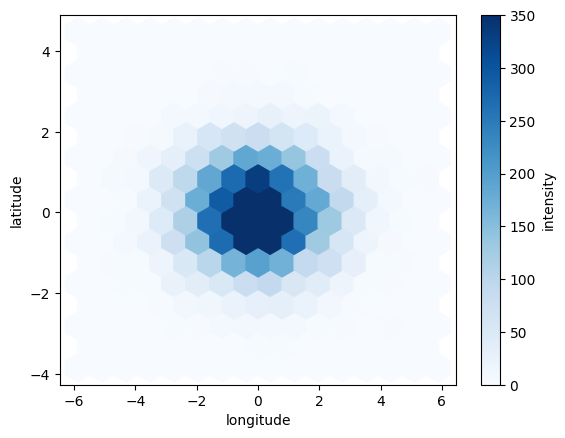

In [9]:
plt.hexbin(df_traffic['longitude'], df_traffic['latitude'], gridsize = 15, cmap = 'Blues', vmin = 0, vmax = 350)
cb = plt.colorbar()
cb.set_label('intensity')
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

##### <font color='chocolate'>1.4. Задание</font>
В двумерном списке дана дневная и ночная температура в Берлине в январе 2024 года: <br>
[[8, 5, 11, 4, 1, 0, -1, -6, -6, -4, -2, 0, 3, 3, 2, 1, 0, 0, 1, 2, 2, 9, 7, 11, 8, 9, 6, 6, 8, 8, 6], <br>
 [6, 6, 9, 1, 0, 1, -2, -8, -8, -7, 0, 1, 3, 3, 1, -1,  -2, -1, -3, 0, -3, 2, 6, 6, 8, 4, 5, 2, 1, 3, 8]] <br>
Постройте тепловую карту по этим данным.

In [25]:
# Список координат
temp = [[8, 5, 11, 4, 1, 0, -1, -6, -6, -4, -2, 0, 3, 3, 2,
         1, 0, 0, 1, 2, 2, 9, 7, 11, 8, 9, 6, 6, 8, 8, 6], 
        [6, 6, 9, 1, 0, 1, -2, -8, -8, -7, 0, 1, 3, 3, 1, -1,
         -2, -1, -3, 0, -3, 2, 6, 6, 8, 4, 5, 2, 1, 3, 8]]

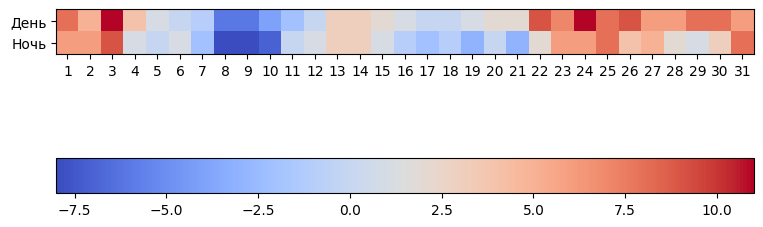

In [63]:
plt.figure(figsize=(9, 9))
plt.imshow(temp, cmap = "coolwarm")
plt.colorbar(location = 'bottom')
plt.xticks(range(len(temp[0])), labels = range(1, len(temp[0])+1))
plt.yticks([0, 1], ['День', 'Ночь'])

plt.show()

### <font color='chocolate'>2. Работа с несколькими фигурами и осями</font>

<b>plt.figure()</b> - это функция, которая используется для создания новой фигуры. <br>
<b>plt.subplot()</b> - это функция, которая используется для добавления подграфиков в фигуру.

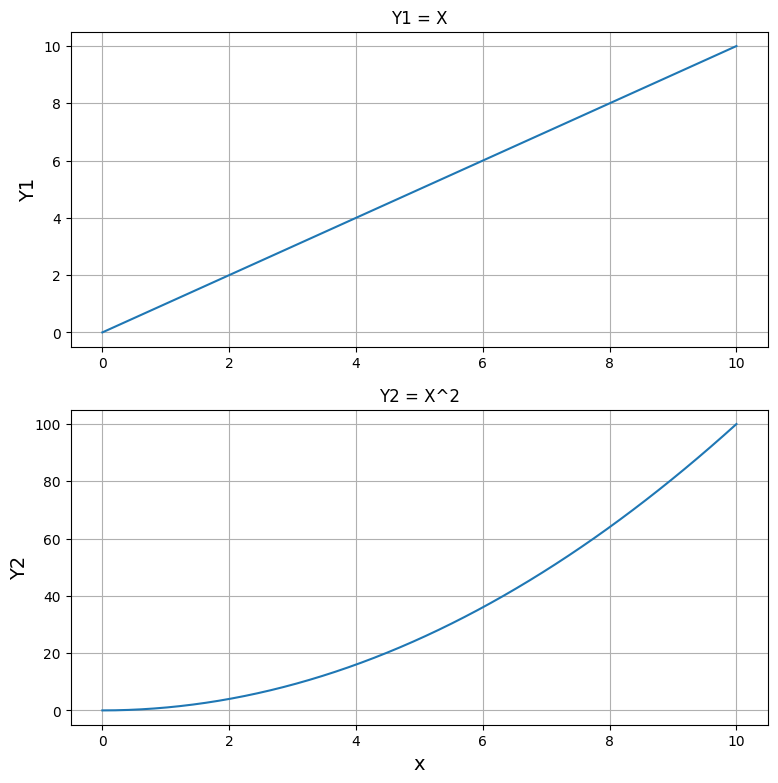

In [66]:
# Способ 1
# Линейная зависимость
x = np.linspace(0, 10, 50) # Возвращает равномерно распределенные числа в указанном интервале.
y1 = x
# Квадратичная зависимость
y2 = [i**2 for i in x]
# Построение графиков
plt.figure(figsize = (9, 9))
plt.subplot(2, 1, 1) # 2 - кол-во строк, 1 - кол-во столбцов, 1 - индекс текущей ячейки)
plt.plot(x, y1)               # построение графика
plt.title("Y1 = X") # заголовок
plt.ylabel("Y1", fontsize = 14) # ось ординат
plt.grid(True)                # включение отображение сетки

plt.subplot(2, 1, 2)
plt.plot(x, y2)               # построение графика
plt.title("Y2 = X^2") # заголовок
plt.xlabel("x", fontsize = 14)  # ось абсцисс
plt.ylabel("Y2", fontsize = 14) # ось ординат
plt.grid(True)                # включение отображение сетки
plt.show()

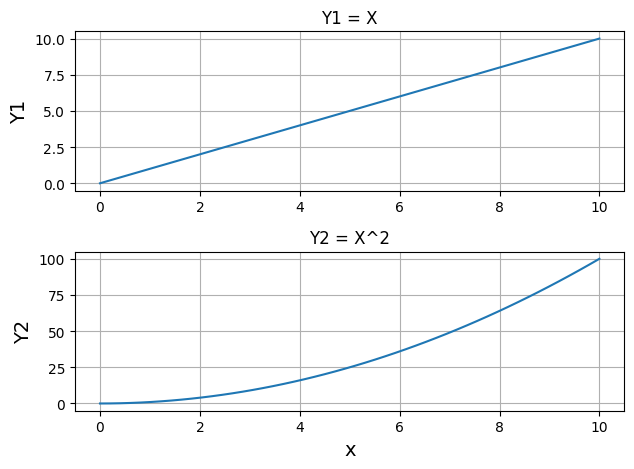

In [67]:
# Способ 2
fig, axes = plt.subplots(2, 1) # 2 - кол-во строк, 1 - кол-во столбцов)
axes[0].plot(x, y1)               # построение графика
axes[0].set_title("Y1 = X") # заголовок
axes[0].set_ylabel("Y1", fontsize = 14) # ось ординат
axes[0].grid(True)                # включение отображение сетки

axes[1].plot(x, y2)               # построение графика
axes[1].set_title("Y2 = X^2") # заголовок
axes[1].set_xlabel("x", fontsize = 14)  # ось абсцисс
axes[1].set_ylabel("Y2", fontsize = 14) # ось ординат
axes[1].grid(True)                # включение отображение сетки
fig.tight_layout() # отступы между графиками
plt.show()

<b> Два подграфика одного рисунка могут также иметь общую ось Х, но разные оси Y </b>

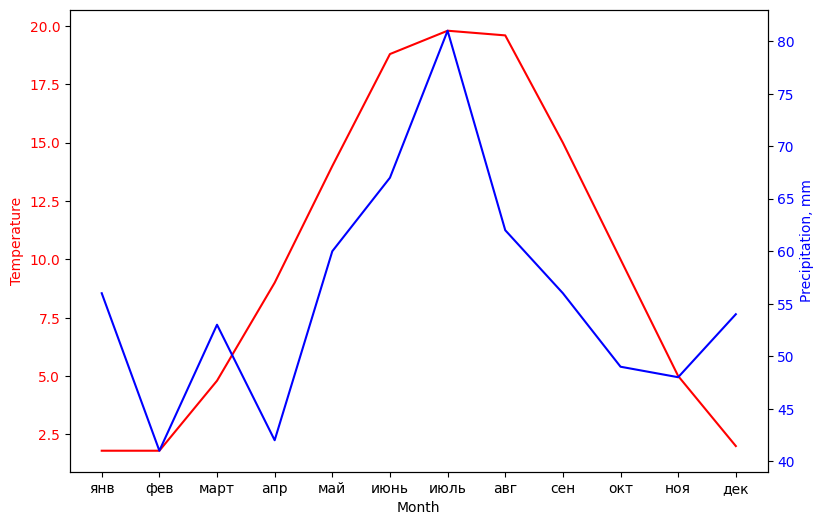

In [70]:
# Сравним среднюю температуру (в градусах Цельсия) и количество осадков (в миллиметрах) в Берлине по месяцам года.

month = ['янв','фев','март','апр','май','июнь','июль','авг','сен','окт','ноя','дек']
temp = [1.8, 1.8, 4.8, 9.0, 14.0, 18.8, 19.8, 19.6, 15.0, 10.0, 5.0, 2.0]
prec = [56, 41, 53, 42, 60, 67, 81, 62, 56, 49, 48, 54]

plt.figure(figsize=(9, 6))
# Функция subplot возвращает оси графика и далее мы можем с ними взаимодействовать
ax1 = plt.subplot() # по умолчани 1, 1, 1
ax1.plot(month, temp, color = 'red')
ax1.set_xlabel('Month')
ax1.set_ylabel("Temperature", color = 'red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(month, prec, color = 'blue')
ax2.set_ylabel('Precipitation, mm', color = 'blue')
ax2.tick_params(axis = 'y', labelcolor='blue')

plt.show()


<b> спользование вложенных графиков </b>

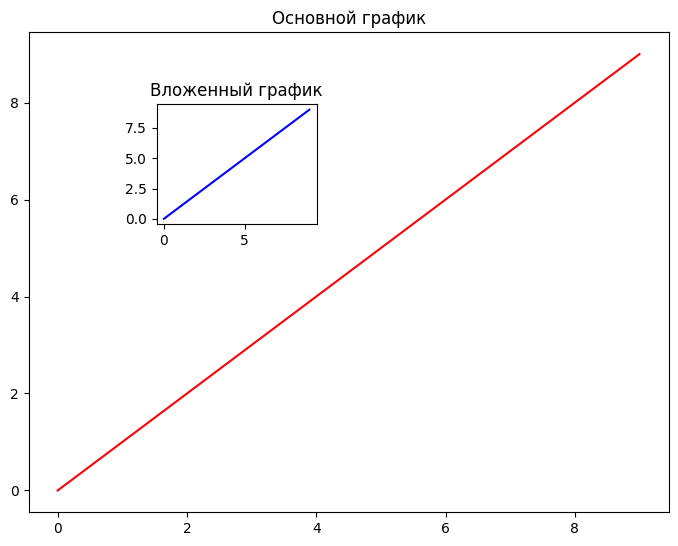

In [15]:
# Основной график
plt.axes([0, 0, 1, 1]) # доли фигуры (от 0 до 1). [left = 0, bottom = 0, width = 1, height = 1]
plt.plot(range(10), color = 'red') # здесь y автоматически = x
plt.title('Основной график')

# Вложенный график
plt.axes([0.2, 0.6, 0.25, 0.25]) # left=0.2, bottom=0.6, width=0.25, height=0.25.
plt.plot(range(10), color = 'blue')
plt.title('Вложенный график')
plt.show()

С помощью функции axes() расположите графики из предыдущего примера рядом друг с другом, одинакового размера.

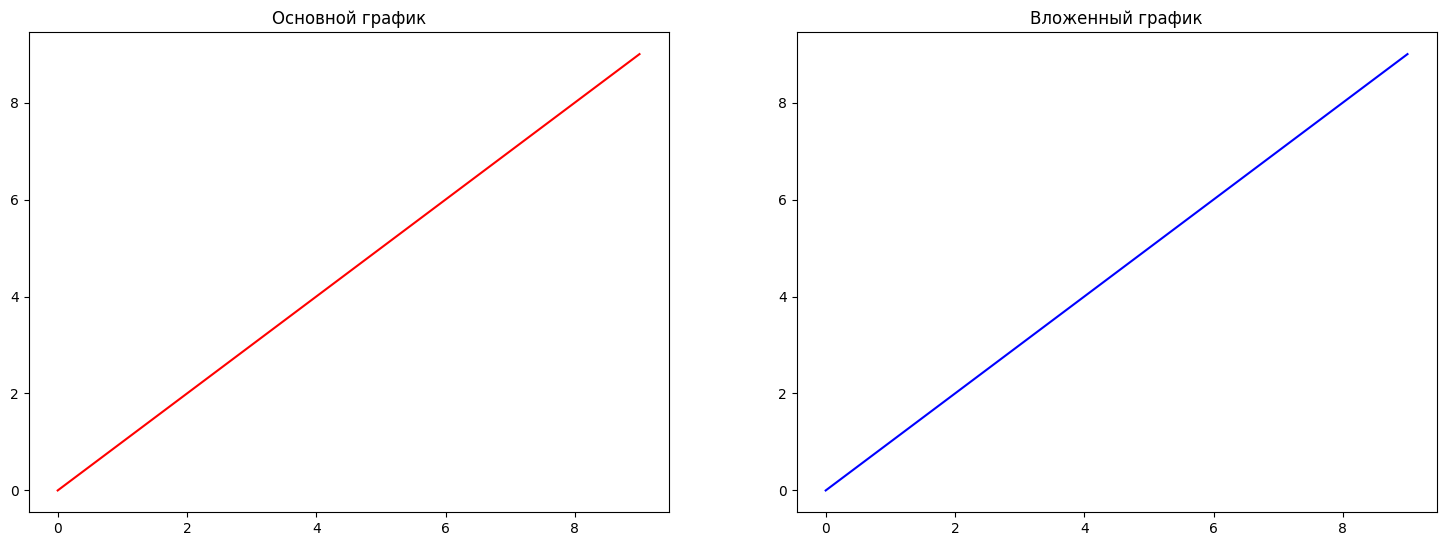

In [72]:
plt.axes([0, 0, 1, 1]) # доли фигуры (от 0 до 1). [left = 0, bottom = 0, width = 1, height = 1]
plt.plot(range(10), color = 'red') # здесь y автоматически = x
plt.title('Основной график')

# Вложенный график
plt.axes([1.2, 0, 1, 1]) # left=0.2, bottom=0.6, width=0.25, height=0.25.
plt.plot(range(10), color = 'blue')
plt.title('Вложенный график')
plt.show()

### <font color='chocolate'>3. Продвинутые возможности</font>

##### <font color='chocolate'>3.1. 3D графики</font>
Практическое применение: <br>
- Анализ зависимости метрик между несколькими переменными.
- Обнаружение оптимальных комбинаций факторов для максимизации результата.

In [16]:
# импорт модуля mplot3d
import mpl_toolkits.mplot3d as m3

In [98]:
%matplotlib inline

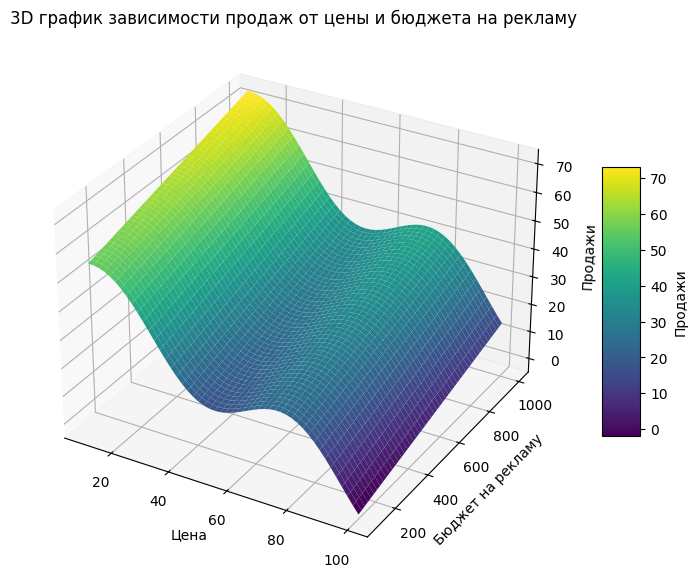

In [77]:
price = np.linspace(10, 100, 50)            # цена товара
ad_budget = np.linspace(100, 1000, 50)      # бюджет на рекламу

# Создаём сетку
X, Y = np.meshgrid(price, ad_budget)

# Функция продаж (условная)
Z = 50 + 2*Y/100 - 0.5*X + np.sin(X/10)*10

fig = plt.figure(figsize = (10,7))
ax = fig.add_subplot(1, 1, 1, projection = '3d')

# Строим поверхность
surf = ax.plot_surface(X, Y, Z, cmap = 'viridis')

# Добавляем подписи осей
ax.set_xlabel('Цена')
ax.set_ylabel('Бюджет на рекламу')
ax.set_zlabel('Продажи')

# Цветовая шкала
fig.colorbar(surf, shrink = 0.5, aspect = 7, label = 'Продажи')

plt.title('3D график зависимости продаж от цены и бюджета на рекламу')
plt.show()

##### <font color='chocolate'>3.2. Контурные графики</font>
Практическое применение:
- Анализ пространственных данных: плотность клиентов, температура, давление, уровень риска и т.д.

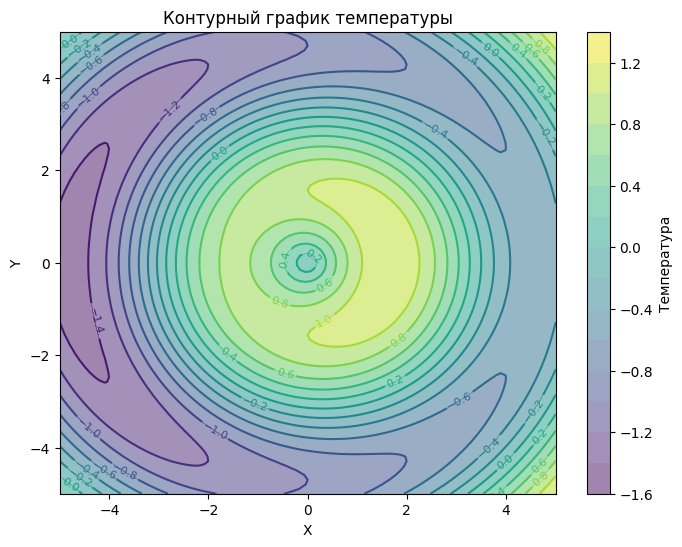

In [79]:
# Линии уровня (contour) — точки с одинаковой температурой.
# Цветовая заливка (contourf) — помогает быстро видеть зоны с высокой и низкой температурой.
# Ближе расположенные линии → быстрые изменения температуры.
# Более редкие линии → плавное изменение температуры.

# Создание сетки координат
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# Пример функции: "температура"
Z = np.sin(np.sqrt(X**2 + Y**2)) + 0.1*X
# Z = X**2 + Y**2

plt.figure(figsize = (8,6))

# Контурные линии
contours = plt.contour(X, Y, Z, levels = 15, cmap = 'viridis') # levels - кол-во контуров
plt.clabel(contours, inline = True, fontsize = 8)  # подписи на линиях

# Контурная заливка
plt.contourf(X, Y, Z, levels = 15, cmap = 'viridis', alpha = 0.5) # alpha: 0 - прозрачный, 1 - непрозрачный

plt.colorbar(label = 'Температура')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Контурный график температуры')
plt.show()

##### <font color='chocolate'>3.3. Визуализация географических данных</font>
<b>Basemap, cartopy</b>

Практическое применение:
- Анализ пространственных данных: плотность клиентов, температура, давление, уровень риска и т.д.

In [19]:
! pip install cartopy

In [20]:
import cartopy.crs as ccrs

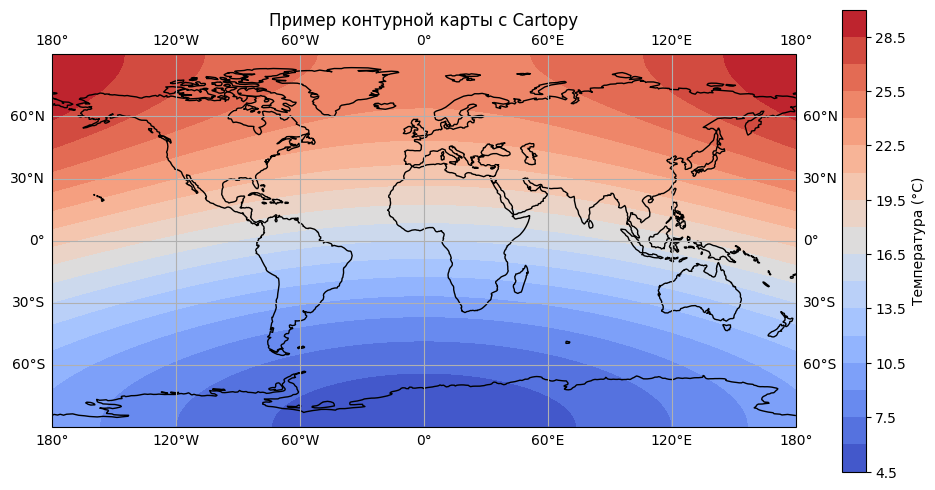

In [21]:
# Создаем глобальную сетку
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
Lon, Lat = np.meshgrid(lon, lat)

# Генерируем примерные данные (например, "температура")
Z = 20 + 10*np.sin(np.radians(Lat)) - 5*np.cos(np.radians(Lon/2))

# Создаем фигуру и ось с проекцией Меркатора
fig, ax = plt.subplots(figsize=(12,6), subplot_kw = {'projection': ccrs.PlateCarree()})
ax.set_global()

# Заполненные контуры
contour = ax.contourf(Lon, Lat, Z, levels=20, cmap='coolwarm', transform=ccrs.PlateCarree())

# Добавляем линии побережья и сетку
ax.coastlines()
ax.gridlines(draw_labels=True)

# Цветовая шкала
fig.colorbar(contour, ax=ax, orientation='vertical', label='Температура (°C)')

plt.title('Пример контурной карты с Cartopy')
plt.show()


### <font color='teal'>4. Решение задач</font>

<b> Задача №1 </b><br>
меются данные о количестве осадков в Берлине по месяцам: <br>
prec = [56, 41, 53, 42, 60, 67, 81, 62, 56, 49, 48, 54] <br>
По этим данным постройте 4 диаграммы: точечный график, гистограмму (4 бина), круговую и столбчатую диаграммы. Графики должны быть расположены в два ряда и два столбца.

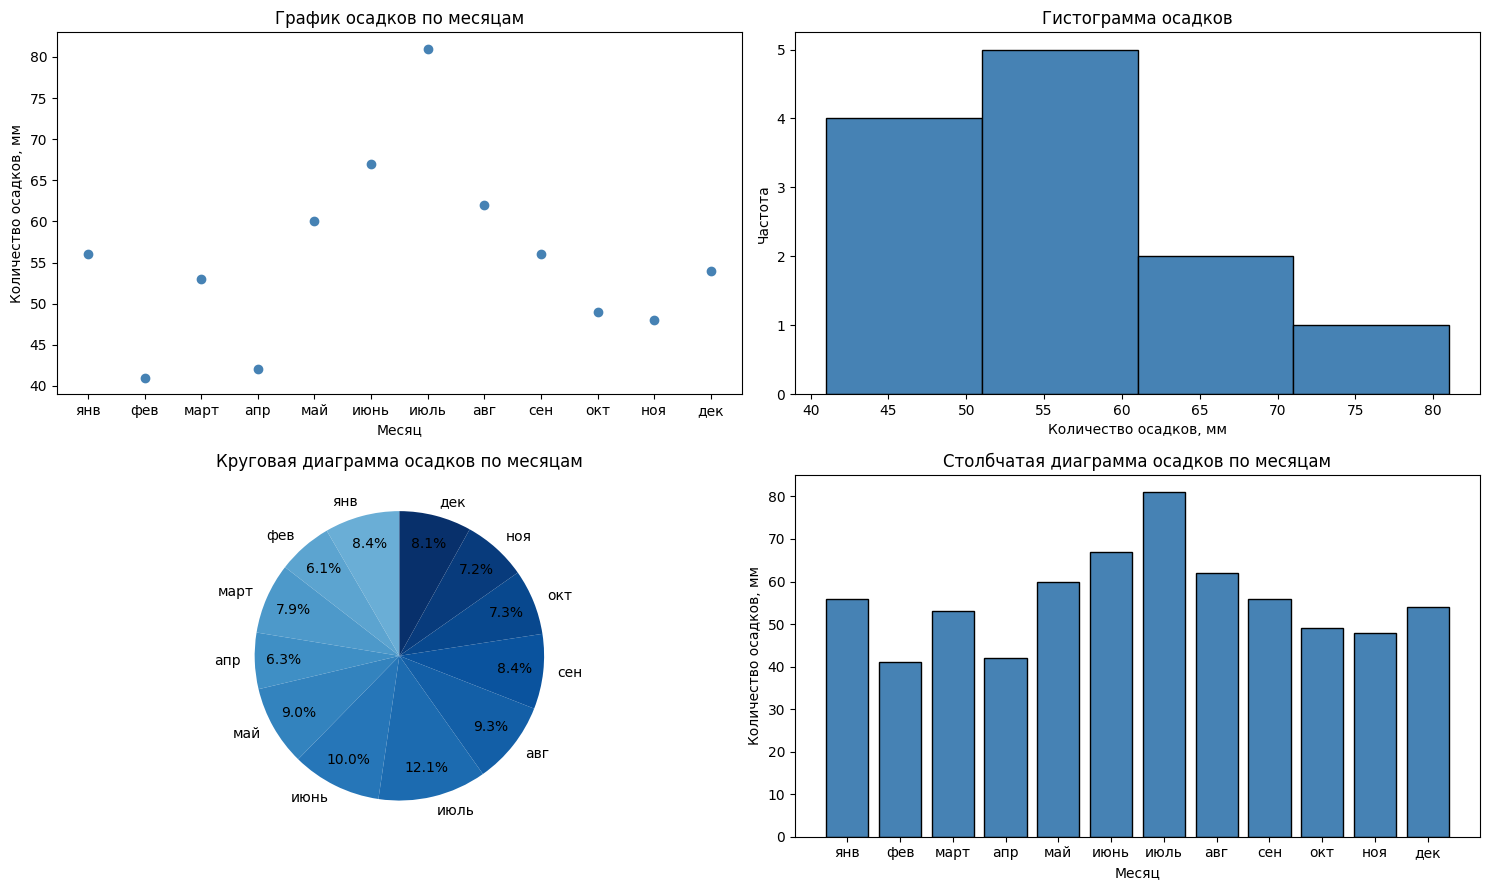

In [109]:
prec = [56, 41, 53, 42, 60, 67, 81, 62, 56, 49, 48, 54]
month = ['янв','фев','март','апр','май','июнь','июль','авг','сен','окт','ноя','дек']

plt.figure(figsize=(15, 9))
plt.subplot(2, 2, 1)
plt.scatter(month, prec, color = 'steelblue')
plt.xlabel('Месяц')
plt.ylabel('Количество осадков, мм')
plt.title('График осадков по месяцам')
plt.tight_layout()

plt.subplot(2, 2, 2)
plt.hist(prec, bins = 4, color = 'steelblue', edgecolor = 'black')
plt.xlabel('Количество осадков, мм')   
plt.ylabel('Частота')
plt.title('Гистограмма осадков')
plt.tight_layout()

plt.subplot(2, 2, 3)
plt.pie(prec, labels = month, autopct='%1.1f%%', startangle=90, pctdistance=0.8, colors = plt.cm.Blues(np.linspace(0.5, 1, len(month))))
plt.title('Круговая диаграмма осадков по месяцам')
plt.tight_layout()

plt.subplot(2, 2, 4)
plt.bar(month, prec, color = 'steelblue', edgecolor = 'black')
plt.xlabel('Месяц')
plt.ylabel('Количество осадков, мм')
plt.title('Столбчатая диаграмма осадков по месяцам')
plt.tight_layout()
plt.show()

<b> Задача №2 </b><br>
На одной системе координат постройте два трехмерных графика: Z=X*Y и Z=-X*Y.

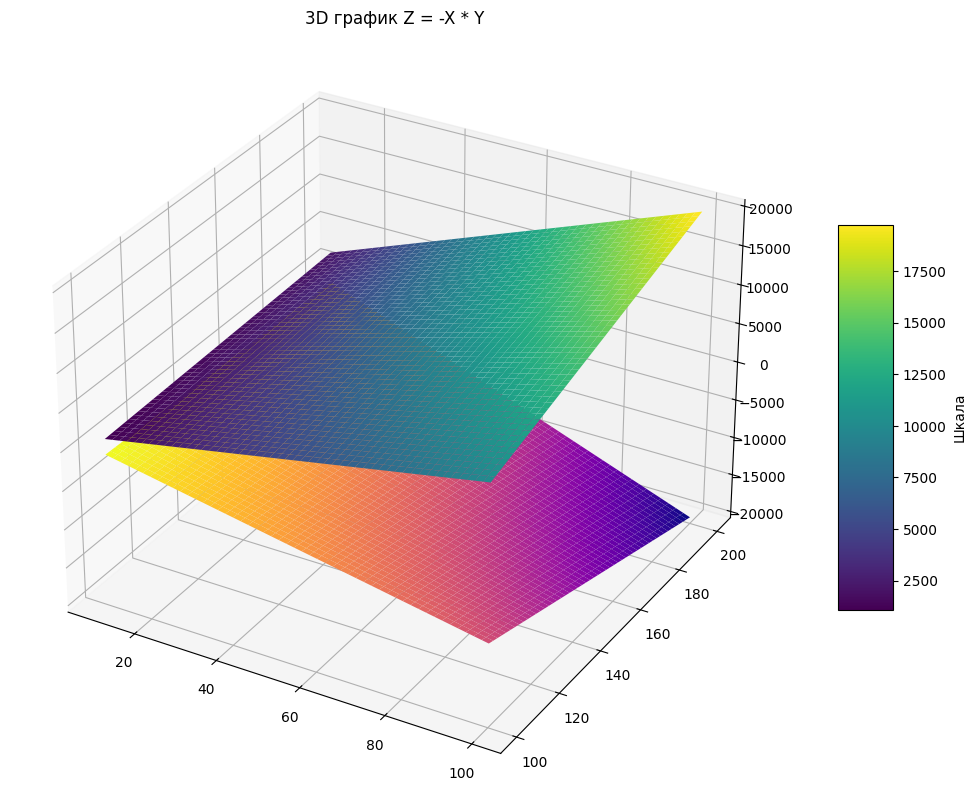

In [124]:
x = np.linspace(10, 100, 500)
y = np.linspace(100, 200, 500)
X, Y = np.meshgrid(x, y)
Z = X * Y

fig = plt.figure(figsize = (15,10))
ax = fig.add_subplot(1, 1, 1, projection = '3d')
surf = ax.plot_surface(X, Y, Z, cmap = 'viridis')
fig.colorbar(surf, shrink = 0.5, aspect = 7, label = 'Шкала')
ax.set_title('3D график Z = X * Y')

ax.can_zoom()
Z = - (X * Y)
surf = ax.plot_surface(X, Y, Z, cmap = 'plasma')
ax.set_title('3D график Z = -X * Y')
plt.show()
